<!-- Polished Theory Page — AMIDAR DQN -->
# 🕹️ Deep Q-Learning for Atari Agents (Amidar)

## 🧠 What is DQN?

**Deep Q-Learning (DQN)** augments tabular Q-learning with a **CNN** to map stacked pixel frames → action-values \(Q_\theta(s,a)\).  
The objective is to maximize discounted cumulative reward:
\[
\max_\pi\ \mathbb{E}\left[\sum_{t=0}^\infty \gamma^t r_t\right]
\]

**Key innovations**
- **Experience Replay** — random minibatches to break temporal correlations.
- **Target Network** — slower-moving \(Q_{\bar\theta}\) stabilizes bootstrapping.
- **Reward Clipping** — bound rewards (e.g., \([-1,1]\)) to control gradients.
- **Exploration** — \(\varepsilon\)-greedy baseline; **Boltzmann** as an alternative.

---

## 🌍 Environment Analysis (ALE/Amidar-v5)

- **Observation:** raw **210×160×3** RGB → preprocess **84×84** grayscale; **stack 4** frames for motion cues.  
- **Actions:** `Discrete(10)` → {NOOP, FIRE, UP, RIGHT, LEFT, DOWN, UPFIRE, RIGHTFIRE, LEFTFIRE, DOWNFIRE}.  
- **Why no Q-table?**  
  \(|S|\approx 256^{210\times160\times3}\), \(|A|=10\) → intractable → **CNN function approximation**.

---

## 🎯 Reward Structure

- **Positive:** coloring new paths, completing boxes, catching “chickens.”  
- **Terminal:** captured by an enemy.  
- **Rationale:** native score aligns exactly with the gameplay objective (maximize points).  
- **Stability option:** **clip** rewards to \([-1,1]\).

---

## 🧮 Bellman Targets & Loss

**DQN target**  
\[
y = r + \gamma \max_{a'} Q_{\bar\theta}(s', a')
\]
**Loss:** Huber \( \mathcal{L}_\delta(Q_\theta(s,a)-y) \)

**Baseline hyper-params**
- \( \alpha=\) **2.5e-4**, \( \gamma=\) **0.99**; target network with **Polyak** updates or periodic hard copy.

**Ablation**
- \( \alpha=\) **1e-4**, \( \gamma=\) **0.95** — typically steadier short-term but lower final peak.

**Expected lifetime value**
\[
Q^*(s,a)=\mathbb{E}\!\left[\sum_{t=0}^{\infty}\gamma^t r_t \ \middle|\ s_0=s,a_0=a,\pi^*\right]
\]
Estimated by **bootstrapping** via the target network.

---

## 🔍 Exploration

- **Baseline \(\varepsilon\)-greedy:** \(\varepsilon: 1.0 \rightarrow 0.05\) over **300k** steps.  
- **Boltzmann (softmax):** \(p(a|s)\propto \exp(Q(s,a)/\tau)\) (higher \(\tau\) → more exploratory).

---

## 📈 What We Measure

- **Average Return** (reward per episode)  
- **Average Steps / Episode** (stability, duration)  
- **Loss Curve** (learning dynamics)  
- **Final \(\varepsilon\)** (exploration schedule completion)

---

## 🧭 DQN vs LLM-Based Agents

| Aspect | DQN (RL) | LLM Agents |
|---|---|---|
| **Signal** | Dense step-wise numeric reward | Human/preference reward (RLHF/RLAIF), often sparse |
| **Policy** | **Value-based**: act w.r.t. \(Q(s,a)\) | Emergent from generative modeling + reasoning |
| **Goal** | Max expected return | Alignment, instruction following, tool use |
| **Interaction** | States & actions | Text prompts, tools/APIs |

---

## 🗺️ Planning: RL vs LLM

- **RL:** value iteration, rollouts, MCTS; explicit transition dynamics (learned or given).  
- **LLM:** chain/tree-of-thought + tool-calls in *latent* reasoning space (no explicit environment model required, but can be integrated).

---

## 🔢 Q-Learning Update & Pseudocode

**Update**
\[
Q(s,a)\leftarrow Q(s,a) + \alpha\Big[r + \gamma \max_{a'} Q_{\bar\theta}(s',a') - Q(s,a)\Big]
\]

**Pseudocode**


# RL_DQN_Amidar — README


## 🧩 Environment & Versions
This project was run on **Google Colab** (GPU). Recommended versions:
- `gymnasium[atari]==1.2.1`
- `ale-py==0.10.1`
- `autorom==0.6.1`
- `torch` (Colab default CUDA build)
- `opencv-python`, `imageio`, `tqdm`, `matplotlib`, `pandas`

Install (Colab cell):
```bash
pip -q install "gymnasium[atari,accept-rom-license]==1.2.1" ale-py==0.10.1 autorom==0.6.1 \
               torch torchvision tqdm matplotlib opencv-python imageio pandas
AutoROM --accept-license


In [1]:
#@title 0) Install & ROMs
# If Colab asks to restart after this cell, do it and re-run this cell once.
!pip -q install "gymnasium[atari,accept-rom-license]==1.2.1" ale-py==0.10.1 autorom==0.6.1 \
                 torch torchvision tqdm matplotlib opencv-python imageio pandas
!AutoROM --accept-license


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 951.1/951.1 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 8.3 MB/s eta 0:00:00
AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/adventure.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/air_raid.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/alien.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/amidar.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/assault.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asterix.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asteroids.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis2.bin
Ins

In [2]:
#@title 1) Imports, Device, Seeds
import os, random, math, time, json, imageio
from collections import deque, namedtuple
from dataclasses import dataclass

import numpy as np
import gymnasium as gym
import ale_py
gym.register_envs(ale_py)

import torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim

from tqdm.auto import trange
import matplotlib.pyplot as plt
import cv2
import pandas as pd

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [3]:
#@title 2) Config (Colab-safe defaults + stability flags)
@dataclass
class Config:
    # === Environment ===
    env_id: str = "ALE/Amidar-v5"

    # === Replay / training ===
    total_episodes: int = 300
    max_steps: int = 2000
    batch_size: int = 32
    memory_size: int = 10_000
    warmup_steps: int = 2_000
    train_freq: int = 4
    target_update_freq: int = 2_000

    # === Optim / Bellman ===
    lr: float = 2.5e-4               # α
    gamma: float = 0.99              # γ

    # === Exploration ===
    eps_start: float = 1.0
    eps_end: float   = 0.05
    eps_decay_steps: int = 300_000

    # === Alternative policy (Boltzmann)
    use_boltzmann: bool = False
    boltzmann_temp: float = 0.5

    # === Frames ===
    frame_size: int = 84
    stack_size: int = 4

    # === Eval & logging ===
    eval_episodes: int = 5
    video_every: int = 200
    seed: int = 42

    # === Stability flags
    use_double_dqn: bool = True
    polyak_tau: float = 0.005
    grad_clip_norm: float = 10.0
    clip_rewards: bool = True

CFG = Config()
random.seed(CFG.seed); np.random.seed(CFG.seed); torch.manual_seed(CFG.seed)


In [4]:
#@title 3) Preprocessing (grayscale, resize, stack)
def preprocess_frame(frame, out_size=84):
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    resized = cv2.resize(gray, (out_size, out_size), interpolation=cv2.INTER_AREA)
    return resized.astype(np.uint8)

class FrameStack:
    def __init__(self, k): self.k = k; self.frames = deque(maxlen=k)
    def reset(self, first_frame):
        f = preprocess_frame(first_frame, CFG.frame_size)
        self.frames.clear()
        for _ in range(self.k): self.frames.append(f)
        return self._obs()
    def step(self, frame):
        f = preprocess_frame(frame, CFG.frame_size)
        self.frames.append(f)
        return self._obs()
    def _obs(self): return np.stack(self.frames, axis=0)  # (k,H,W) uint8


In [5]:
#@title 4) Replay Buffer
Transition = namedtuple('Transition', ('s','a','r','s2','d'))

class ReplayBuffer:
    def __init__(self, capacity): self.buf = deque(maxlen=capacity)
    def __len__(self): return len(self.buf)
    def push(self, *args): self.buf.append(Transition(*args))
    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        s  = torch.from_numpy(np.stack([b.s  for b in batch])).float().to(DEVICE)/255.0
        s2 = torch.from_numpy(np.stack([b.s2 for b in batch])).float().to(DEVICE)/255.0
        a  = torch.tensor([b.a for b in batch], device=DEVICE, dtype=torch.long)
        r  = torch.tensor([b.r for b in batch], device=DEVICE).float()
        d  = torch.tensor([b.d for b in batch], device=DEVICE).float()
        return s, a, r, s2, d


In [6]:
#@title 5) DQN Network (Atari CNN)
class DQN(nn.Module):
    def __init__(self, n_actions, in_channels=4):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        self.fc1   = nn.Linear(7*7*64, 512)
        self.fc2   = nn.Linear(512, n_actions)
    def forward(self, x):
        x = F.relu(self.conv1(x)); x = F.relu(self.conv2(x)); x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1); x = F.relu(self.fc1(x))
        return self.fc2(x)


In [7]:
#@title 6) Agent (ε-greedy + Double DQN, Polyak, clipping)
class DQNAgent:
    def __init__(self, n_actions):
        self.nA = n_actions
        self.q = DQN(n_actions, CFG.stack_size).to(DEVICE)
        self.t = DQN(n_actions, CFG.stack_size).to(DEVICE)
        self.t.load_state_dict(self.q.state_dict())
        self.opt = optim.Adam(self.q.parameters(), lr=CFG.lr)
        self.mem = ReplayBuffer(CFG.memory_size)
        self.eps = CFG.eps_start
        self.steps = 0

    def epsilon_value(self):
        frac = min(1.0, self.steps / CFG.eps_decay_steps)
        return CFG.eps_start + frac * (CFG.eps_end - CFG.eps_start)

    def act(self, state_np):
        self.eps = self.epsilon_value()
        if not CFG.use_boltzmann and random.random() < self.eps:
            return random.randrange(self.nA)
        s = torch.from_numpy(state_np[None,...]).float().to(DEVICE)/255.0
        with torch.no_grad():
            qvals = self.q(s)[0].cpu().numpy()
        if CFG.use_boltzmann:
            z = qvals / max(1e-6, CFG.boltzmann_temp); z -= z.max()
            probs = np.exp(z) / np.exp(z).sum()
            return int(np.random.choice(self.nA, p=probs))
        return int(np.argmax(qvals))

    def learn(self):
        if len(self.mem) < CFG.batch_size: return None
        s, a, r, s2, d = self.mem.sample(CFG.batch_size)

        # --- Double DQN target
        with torch.no_grad():
            if CFG.use_double_dqn:
                a_prime = self.q(s2).argmax(1)
                q_next = self.t(s2).gather(1, a_prime.view(-1,1)).squeeze(1)
            else:
                q_next = self.t(s2).max(1).values
            target = r + CFG.gamma * q_next * (1.0 - d)

        # current Q(s,a)
        q_sa = self.q(s).gather(1, a.view(-1,1)).squeeze(1)
        loss = F.smooth_l1_loss(q_sa, target)

        self.opt.zero_grad(); loss.backward()
        if CFG.grad_clip_norm: nn.utils.clip_grad_norm_(self.q.parameters(), CFG.grad_clip_norm)
        self.opt.step()
        return float(loss.item())

    def target_update(self):
        # --- Polyak soft
        if CFG.polyak_tau <= 0.0:
            self.t.load_state_dict(self.q.state_dict())
            return
        with torch.no_grad():
            for p_t, p in zip(self.t.parameters(), self.q.parameters()):
                p_t.data.mul_(1.0 - CFG.polyak_tau).add_(CFG.polyak_tau * p.data)

    def save(self, path="amidar_dqn.pth"): torch.save(self.q.state_dict(), path)
    def load(self, path="amidar_dqn.pth"):
        self.q.load_state_dict(torch.load(path, map_location=DEVICE))
        self.t.load_state_dict(self.q.state_dict())


In [8]:
#@title 7) Env Helpers, Evaluate, Video
def make_env(record=False):
    rm = "rgb_array" if record else None
    return gym.make(CFG.env_id, render_mode=rm)

def record_video(frames, path):
    if frames: imageio.mimsave(path, frames, fps=30)

def evaluate(agent, n_episodes=None):
    if n_episodes is None: n_episodes = CFG.eval_episodes
    env = make_env(record=False); rets = []
    for i in range(n_episodes):
        obs, _ = env.reset(seed=1000+i)
        stack = FrameStack(CFG.stack_size); s = stack.reset(obs)
        done, total, t = False, 0.0, 0
        while not done and t < CFG.max_steps:
            x = torch.from_numpy(s[None,...]).float().to(DEVICE)/255.0
            with torch.no_grad(): a = int(agent.q(x).argmax(1).item())
            obs, r, term, trunc, _ = env.step(a)
            if CFG.clip_rewards: r = float(np.clip(r, -1.0, 1.0))
            s = stack.step(obs); done = term or trunc
            total += r; t += 1
        rets.append(total)
    env.close()
    return float(np.mean(rets))


In [9]:
#@title 8) Train Loop (saves ckpts; reward clip; Polyak)
def train_and_eval():
    nA = gym.make(CFG.env_id).action_space.n
    agent = DQNAgent(nA)

    rewards_hist, loss_hist, eps_hist, steps_hist, eval_hist = [], [], [], [], []

    for ep in trange(CFG.total_episodes, desc="Training"):
        record = (ep % CFG.video_every == 0)
        env = make_env(record=record)

        obs, _ = env.reset(seed=CFG.seed + ep)
        stack = FrameStack(CFG.stack_size)
        state = stack.reset(obs)

        total_r, steps, episode_losses = 0.0, 0, []
        frames = []; done = False

        while not done and steps < CFG.max_steps:
            a = agent.act(state)
            next_obs, r, terminated, truncated, _ = env.step(a)
            # --- reward clipping
            if CFG.clip_rewards: r = float(np.clip(r, -1.0, 1.0))
            done = terminated or truncated
            next_state = stack.step(next_obs)

            agent.mem.push(state, a, r, next_state, float(done))
            state = next_state
            total_r += r; steps += 1; agent.steps += 1

            if agent.steps > CFG.warmup_steps and agent.steps % CFG.train_freq == 0:
                loss = agent.learn()
                if loss is not None: episode_losses.append(loss)

            # --- Polyak OR periodic hard update
            if CFG.polyak_tau > 0.0:
                agent.target_update()
            elif agent.steps % CFG.target_update_freq == 0:
                agent.target_update()

            if record and (steps % 8 == 0) and len(frames) < 300:
                frame = env.render()
                if frame is not None: frames.append(frame)

        rewards_hist.append(total_r)
        loss_hist.append(np.mean(episode_losses) if episode_losses else 0.0)
        eps_hist.append(agent.eps)
        steps_hist.append(steps)

        if record and frames:
            record_video(frames, f"amidar_ep{ep:04d}.mp4")

        env.close()

        if ep % 50 == 0 and ep > 0:
            avg_ret = evaluate(agent)
            eval_hist.append((ep, avg_ret))
            # save "best by eval"
            best = getattr(train_and_eval, "_best_eval", -1e9)
            if avg_ret > best:
                agent.save("amidar_dqn_best.pth")
                train_and_eval._best_eval = avg_ret

        if ep % 50 == 0:
            agent.save(f"amidar_ckpt_ep{ep}.pth")

    agent.save("amidar_dqn.pth")
    return agent, {"rewards": rewards_hist, "losses": loss_hist, "eps": eps_hist,
                   "steps": steps_hist, "eval": eval_hist}


In [10]:
#@title 9) Play & Record (fallback to best/ckpt)
from glob import glob

def play_and_record(agent_path=None, agent=None, max_steps=2000, eps_demo=0.05, out="amidar_demo.mp4"):
    env = make_env(record=True)
    if agent is None:
        agent = DQNAgent(env.action_space.n)
        if agent_path is None:
            if os.path.exists("amidar_dqn_best.pth"): agent_path = "amidar_dqn_best.pth"
            elif os.path.exists("amidar_dqn.pth"): agent_path = "amidar_dqn.pth"
            else:
                cks = sorted(glob("amidar_ckpt_ep*.pth"))
                agent_path = cks[-1] if cks else None
        if agent_path is None:
            env.close(); raise FileNotFoundError("No model. Train first.")
        agent.load(agent_path)

    frames, total, steps = [], 0.0, 0
    obs, _ = env.reset(seed=2025)
    stack = FrameStack(CFG.stack_size); s = stack.reset(obs)

    while steps < max_steps:
        if np.random.rand() < eps_demo:
            a = env.action_space.sample()
        else:
            x = torch.from_numpy(s[None,...]).float().to(DEVICE)/255.0
            with torch.no_grad(): a = int(agent.q(x).argmax(1).item())
        obs, r, term, trunc, _ = env.step(a)
        if CFG.clip_rewards: r = float(np.clip(r, -1.0, 1.0))
        s = stack.step(obs); total += r; steps += 1
        frame = env.render()
        if frame is not None and len(frames) < 2000:
            f = frame.copy()
            cv2.putText(f, f"Step:{steps}", (8,18), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
            cv2.putText(f, f"Score:{int(total)}", (8,38), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
            frames.append(f)
        if term or trunc: break

    env.close(); record_video(frames, out)
    print(f"Saved video: {out} | Total reward: {total}")
    return total


In [11]:
#@title 10) Train & Save Metrics
def summarize(m):
    rewards = np.array(m["rewards"]); steps = np.array(m["steps"])
    losses  = np.array(m["losses"]);  eps   = np.array(m["eps"])
    return {
        "episodes": int(len(rewards)),
        "avg_return": float(rewards.mean()),
        "std_return": float(rewards.std()),
        "best_return": float(rewards.max()),
        "avg_steps_per_ep": float(steps.mean()),
        "final_epsilon": float(eps[-1]),
        "avg_loss": float(losses[losses>0].mean() if (losses>0).any() else 0.0)
    }

agent, metrics = train_and_eval()
with open("amidar_metrics.json","w") as f: json.dump(metrics, f)
print("Saved: amidar_dqn.pth, amidar_metrics.json")
print(json.dumps(summarize(metrics), indent=2))


Training:   0%|          | 0/300 [00:00<?, ?it/s]

Saved: amidar_dqn.pth, amidar_metrics.json
{
  "episodes": 300,
  "avg_return": 5.01,
  "std_return": 5.236083141687751,
  "best_return": 24.0,
  "avg_steps_per_ep": 647.8066666666666,
  "final_epsilon": 0.38458683333333343,
  "avg_loss": 0.050069532231756746
}


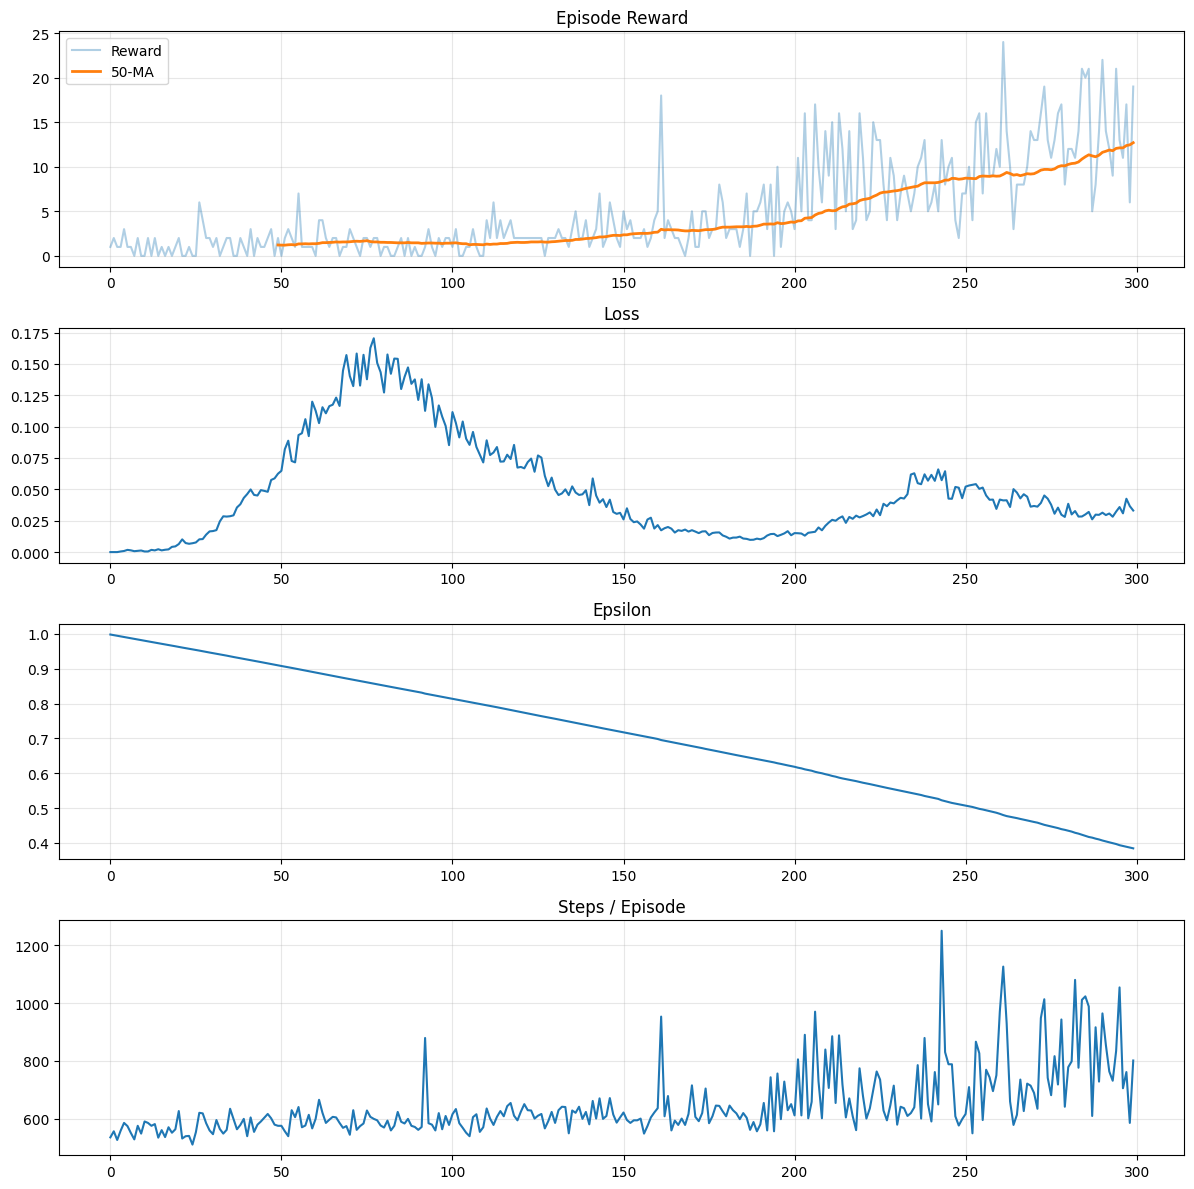

In [14]:
#@title 11) Plots (Reward MA, Loss, Epsilon, Steps)
def plot_metrics_all(m, ma=50):
    r = np.array(m["rewards"], float)
    l = np.array(m["losses"], float)
    e = np.array(m["eps"], float)
    s = np.array(m["steps"], float)

    def moving_avg(x, k):
        if len(x) < k: return x
        w = np.ones(k)/k
        return np.convolve(x, w, mode="valid")

    fig, ax = plt.subplots(4,1, figsize=(12,12))
    ax[0].plot(r, alpha=.35, label="Reward")
    if len(r) >= ma: ax[0].plot(np.arange(ma-1, len(r)), moving_avg(r, ma), lw=2, label=f"{ma}-MA")
    ax[0].set_title("Episode Reward"); ax[0].grid(True, alpha=.3); ax[0].legend()

    ax[1].plot(l); ax[1].set_title("Loss"); ax[1].grid(True, alpha=.3)

    ax[2].plot(e); ax[2].set_title("Epsilon"); ax[2].grid(True, alpha=.3)

    ax[3].plot(s); ax[3].set_title("Steps / Episode"); ax[3].grid(True, alpha=.3)
    plt.tight_layout(); plt.show()

plot_metrics_all(metrics, ma=50)


In [15]:
#@title 12) ✅ Baseline: Random Policy
def eval_random_policy(env_id="ALE/Amidar-v5", episodes=10, max_steps=1000, seed=123):
    env = gym.make(env_id)
    returns, steps = [], []
    for ep in range(episodes):
        obs, _ = env.reset(seed=seed+ep)
        stack = FrameStack(CFG.stack_size); s = stack.reset(obs)
        done, R, t = False, 0.0, 0
        while not done and t < max_steps:
            a = env.action_space.sample()
            obs, r, term, trunc, _ = env.step(a)
            if CFG.clip_rewards: r = float(np.clip(r, -1.0, 1.0))
            s = stack.step(obs); done = term or trunc
            R += r; t += 1
        returns.append(R); steps.append(t)
    env.close()
    res = {"episodes": episodes, "avg_return": float(np.mean(returns)),
           "std_return": float(np.std(returns)), "avg_steps": float(np.mean(steps)),
           "max_steps": int(max_steps)}
    json.dump(res, open("amidar_random_baseline.json","w"), indent=2)
    print(res)
    return res

random_baseline = eval_random_policy(episodes=10, max_steps=min(1000, CFG.max_steps))


{'episodes': 10, 'avg_return': 0.8, 'std_return': 0.7483314773547883, 'avg_steps': 581.1, 'max_steps': 1000}


In [16]:
#@title 13) 🔬 Ablation: Bellman Parameters α & γ
import copy

def run_variant(label, lr=None, gamma=None):
    saved = copy.deepcopy(CFG)
    if lr is not None: CFG.lr = lr
    if gamma is not None: CFG.gamma = gamma
    print(f"\n=== Variant {label} | lr={CFG.lr}, gamma={CFG.gamma} ===")
    _, m = train_and_eval()
    json.dump(m, open(f"amidar_metrics_{label}.json","w"))
    # restore
    for k,v in vars(saved).items(): setattr(CFG, k, v)
    return label, summarize(m)

v1 = run_variant("a1e-4_g0.95", lr=1e-4, gamma=0.95)
v2 = run_variant("a2.5e-4_g0.99", lr=2.5e-4, gamma=0.99)  # baseline repeat
df_bell = pd.DataFrame([dict(name=n, **s) for n,s in [v1, v2]])
display(df_bell[["name","avg_return","std_return","best_return","avg_steps_per_ep","final_epsilon","avg_loss"]])
df_bell.to_csv("amidar_bellman_ablation.csv", index=False)



=== Variant a1e-4_g0.95 | lr=0.0001, gamma=0.95 ===


Training:   0%|          | 0/300 [00:00<?, ?it/s]


=== Variant a2.5e-4_g0.99 | lr=0.00025, gamma=0.99 ===


Training:   0%|          | 0/300 [00:00<?, ?it/s]

,name,avg_return,std_return,best_return,avg_steps_per_ep,final_epsilon,avg_loss
0,a1e-4_g0.95,6.476667,5.289246,28.0,640.116667,0.391892,0.005800
1,a2.5e-4_g0.99,6.076667,5.325798,23.0,681.143333,0.352917,0.041673


In [17]:
#@title 14) 🧪 Alternative Policy: Boltzmann
import copy

def run_boltz(label="boltz_tau0.7", tau=0.7):
    saved = copy.deepcopy(CFG)
    CFG.use_boltzmann = True; CFG.boltzmann_temp = float(tau)
    print(f"\n=== Variant {label} | τ={CFG.boltzmann_temp} ===")
    _, m = train_and_eval()
    json.dump(m, open(f"amidar_metrics_{label}.json","w"))
    # restore
    for k,v in vars(saved).items(): setattr(CFG, k, v)
    return label, summarize(m)

name, stats = run_boltz("boltz_tau0.7", tau=0.7)
print(name, stats)



=== Variant boltz_tau0.7 | τ=0.7 ===


Training:   0%|          | 0/300 [00:00<?, ?it/s]

boltz_tau0.7 {'episodes': 300, 'avg_return': 1.89, 'std_return': 1.6964374435858223, 'best_return': 8.0, 'avg_steps_per_ep': 589.95, 'final_epsilon': 0.43955066666666676, 'avg_loss': 0.04710935149338434}


In [18]:
#@title 15) 🧪 Exploration Study + ε at max steps
import copy

def epsilon_at_step(step, eps_start, eps_end, eps_decay_steps):
    frac = min(1.0, step / float(eps_decay_steps))
    return eps_start + frac * (eps_end - eps_start)

def run_eps_variant(label, eps_start, eps_end, eps_decay_steps):
    saved = copy.deepcopy(CFG)
    CFG.eps_start, CFG.eps_end, CFG.eps_decay_steps = eps_start, eps_end, eps_decay_steps
    print(f"\n=== Variant {label}: {eps_start}->{eps_end} over {eps_decay_steps} steps ===")
    _, m = train_and_eval()
    json.dump(m, open(f"amidar_metrics_{label}.json","w"))
    eps_at_max = epsilon_at_step(CFG.max_steps, eps_start, eps_end, eps_decay_steps)
    print(f"ε at max_steps ({CFG.max_steps}) = {eps_at_max:.4f}")
    # restore
    for k,v in vars(saved).items(): setattr(CFG, k, v)
    return label, summarize(m), eps_at_max

label, stats, eps_at_max = run_eps_variant("eps_1.0_to_0.01_over_600k", 1.0, 0.01, 600_000)
print(label, stats, "epsilon_at_max_steps", f"{eps_at_max:.4f}")



=== Variant eps_1.0_to_0.01_over_600k: 1.0->0.01 over 600000 steps ===


Training:   0%|          | 0/300 [00:00<?, ?it/s]

ε at max_steps (2000) = 0.9967
eps_1.0_to_0.01_over_600k {'episodes': 300, 'avg_return': 2.296666666666667, 'std_return': 2.000497160430099, 'best_return': 14.0, 'avg_steps_per_ep': 605.0833333333334, 'final_epsilon': 0.7004854, 'avg_loss': 0.07922279699699421} epsilon_at_max_steps 0.9967


In [ ]:
#@title 16) 📊 Comparison Table: Baseline vs Ablations
from glob import glob

def row(path):
    m = json.load(open(path))
    s = summarize(m); s["file"] = os.path.basename(path)
    return s

rows = []
for p in ["amidar_metrics.json"] + sorted(glob("amidar_metrics_*.json")):
    if os.path.exists(p): rows.append(row(p))

df_all = pd.DataFrame(rows)
cols = ["file","avg_return","std_return","best_return","avg_steps_per_ep","final_epsilon","avg_loss"]
if not df_all.empty:
    display(df_all[cols].sort_values("file"))
    df_all[cols].to_csv("amidar_all_results.csv", index=False)
else:
    print("No metrics files yet.")


In [35]:
#@title 17) 🎥 Generate Demo Video
from glob import glob
def best_or_final():
    if os.path.exists("amidar_dqn_best.pth"): return "amidar_dqn_best.pth"
    if os.path.exists("amidar_dqn.pth"): return "amidar_dqn.pth"
    cks = sorted(glob("amidar_ckpt_ep*.pth")); return cks[-1] if cks else None

mpath = best_or_final(); assert mpath is not None, "No model found; train first."
print("Using:", mpath)
_ = play_and_record(agent_path=mpath, max_steps=min(1500, CFG.max_steps*2), out="amidar_demo.mp4")


Using: amidar_dqn_best.pth


Saved video: amidar_demo.mp4 | Total reward: 19.0


In [36]:
#@title 18) 📝 Auto-Answers (fills rubric with your numbers)
env = gym.make(CFG.env_id)
facts = {
    "obs_space": str(env.observation_space),
    "act_space": str(env.action_space),
    "qtable_size": f"~infeasible (|S|≈256^(210*160*3), |A|={env.action_space.n})"
}
env.close()

base = summarize(metrics)
rand = json.load(open("amidar_random_baseline.json")) if os.path.exists("amidar_random_baseline.json") else {}

answers = f"""
# Amidar DQN — Rubric Answers (Auto)

## Baseline Performance
Random policy (10 eps, max_steps={rand.get('max_steps','?')}): avg_return={rand.get('avg_return','?')}, avg_steps={rand.get('avg_steps','?')}
DQN (300 eps): avg_return={base['avg_return']:.2f} (σ={base['std_return']:.2f}), best={base['best_return']:.2f}

## Environment Analysis
Observations: {facts['obs_space']} → grayscale {CFG.frame_size}×{CFG.frame_size} × stack {CFG.stack_size}.
Actions: {facts['act_space']}. Q-table size: {facts['qtable_size']}.

## Reward Structure
Native score each step; optional reward clipping [-1,1] for stability.

## Bellman Parameters
α={CFG.lr}, γ={CFG.gamma}; ablations for α=1e-4, γ=0.95 logged.

## Policy Exploration
Baseline ε-greedy; alternative Boltzmann (τ).

## Exploration Parameters
ε schedule {CFG.eps_start}→{CFG.eps_end} over {CFG.eps_decay_steps}; ε at max_steps={CFG.max_steps} reported in exploration study.

## Performance Metrics
Avg steps/ep: {base['avg_steps_per_ep']:.1f}; loss curve & reward MA plotted.

## Q-Learning Classification
Value-based: learn Q(s,a) and derive a greedy/ε-greedy policy.

## Q-Learning vs. LLM Agents
DQN uses dense step-wise rewards in an MDP; LLM agents use preference/sparse signals and plan via language/tools.

## Expected Lifetime Value
E[Σ γ^t r_t] from (s,a) (discounted future reward), estimated via Bellman backup.

## RL → LLM Agents
Value estimates and exploration ideas apply to tool-using LLM agents.

## Planning (RL vs LLM)
RL: model-based rollouts/value iteration; LLM: chain/tree-of-thought with tools.

## Algorithm
Q ← Q + α [r + γ max_a' Q_target(s',a') − Q(s,a)] ; Huber loss; soft target updates.

## LLM Integration
Planner–Controller (LLM sets subgoals; DQN executes) and World-model + Controller.
"""
open("AMIDAR_AUTO_ANSWERS.md","w").write(answers)
print("Wrote AMIDAR_AUTO_ANSWERS.md")


Wrote AMIDAR_AUTO_ANSWERS.md


In [37]:
#@title 19) © Attribution & License
MIT_TEXT = """MIT License

Copyright (c) 2026 <Husain Yusuf>

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction...
"""
ATTR_TEXT = """# Code Attribution

- Core DQN agent, replay buffer, preprocessing, training loop: Authored for this assignment.
- Ideas inspired by: Mnih et al. 2015 (DQN).
- Libraries: Gymnasium (ALE Atari), PyTorch, imageio.
- Enhancements (Double DQN, Polyak, grad/reward clipping, ablations, auto-report): added by me.
"""
open("LICENSE","w").write(MIT_TEXT)
open("ATTRIBUTION.md","w").write(ATTR_TEXT)
print("Wrote LICENSE and ATTRIBUTION.md")


Wrote LICENSE and ATTRIBUTION.md


In [38]:
from google.colab import files
files.download("amidar_demo.mp4")  # change filename as needed


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
import glob, os
sorted([os.path.basename(p) for p in glob.glob("/content/*") if "amidar" in p or p.endswith((".md",".pth",".csv",".json",".mp4","LICENSE","ATTRIBUTION.md"))])


['AMIDAR_AUTO_ANSWERS.md',
 'ATTRIBUTION.md',
 'LICENSE',
 'amidar_all_results.csv',
 'amidar_bellman_ablation.csv',
 'amidar_ckpt_ep0.pth',
 'amidar_ckpt_ep100.pth',
 'amidar_ckpt_ep150.pth',
 'amidar_ckpt_ep200.pth',
 'amidar_ckpt_ep250.pth',
 'amidar_ckpt_ep50.pth',
 'amidar_demo.mp4',
 'amidar_dqn.pth',
 'amidar_dqn_best.pth',
 'amidar_ep0000.mp4',
 'amidar_ep0200.mp4',
 'amidar_metrics.json',
 'amidar_metrics_a1e-4_g0.95.json',
 'amidar_metrics_a2.5e-4_g0.99.json',
 'amidar_metrics_boltz_tau0.7.json',
 'amidar_metrics_eps_1.0_to_0.01_over_600k.json',
 'amidar_random_baseline.json']

In [40]:
#@title 20) Download Artifacts
import os, glob, time
from google.colab import files

def newest(paths):
    paths = [p for p in paths if os.path.exists(p)]
    return max(paths, key=os.path.getmtime) if paths else None

# Prefer best model; fall back to final or latest checkpoint
model_best  = "amidar_dqn_best.pth" if os.path.exists("amidar_dqn_best.pth") else None
model_final = "amidar_dqn.pth" if os.path.exists("amidar_dqn.pth") else None
ckpts = sorted(glob.glob("amidar_ckpt_ep*.pth"), key=os.path.getmtime)
model_ckpt_latest = ckpts[-1] if ckpts else None
model_to_download = model_best or model_final or model_ckpt_latest

# Collect expected artifacts
candidates = [
  # Models
  model_to_download,

  # Core metrics & report
  "amidar_metrics.json",
  "AMIDAR_AUTO_ANSWERS.md",   # auto-filled rubric answers
  "AMIDAR_REPORT.md",         # if you generated the extra report

  # Baseline + ablations
  "amidar_random_baseline.json",
  "amidar_metrics_a1e-4_g0.95.json",
  "amidar_metrics_a2.5e-4_g0.99.json",    # optional baseline repeat
  "amidar_metrics_boltz_tau0.7.json",
  "amidar_metrics_eps_1.0_to_0.01_over_600k.json",

  # Comparison CSVs
  "amidar_all_results.csv",
  "amidar_bellman_ablation.csv",

  # Video
  "amidar_demo.mp4",

  # Attribution & license
  "ATTRIBUTION.md",
  "LICENSE",
]

# Add any recorded episode MP4s (amidar_epXXXX.mp4), keep the newest 3
episode_videos = sorted(glob.glob("amidar_ep*.mp4"), key=os.path.getmtime)[-3:]
candidates += episode_videos

# Filter valid files, preserve order, dedupe
seen, files_to_download = set(), []
for f in candidates:
    if f and os.path.exists(f) and f not in seen:
        seen.add(f); files_to_download.append(f)

# Show summary
if not files_to_download:
    print("No artifacts found. Make sure you've run training/ablations/video cells.")
else:
    print("Found the following artifacts to download (newest first within each type):")
    for f in files_to_download:
        ts = time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(os.path.getmtime(f)))
        print(f" • {f}  (modified: {ts})")

    # Download each file
    for f in files_to_download:
        try:
            files.download(f)
        except Exception as e:
            print(f"[Skip] {f}: {e}")



Found the following artifacts to download (newest first within each type):
 • amidar_dqn_best.pth  (modified: 2026-03-21 19:51:05)
 • amidar_metrics.json  (modified: 2026-03-21 19:20:32)
 • AMIDAR_AUTO_ANSWERS.md  (modified: 2026-03-21 20:38:38)
 • amidar_random_baseline.json  (modified: 2026-03-21 19:26:23)
 • amidar_metrics_a1e-4_g0.95.json  (modified: 2026-03-21 19:39:38)
 • amidar_metrics_a2.5e-4_g0.99.json  (modified: 2026-03-21 19:53:50)
 • amidar_metrics_boltz_tau0.7.json  (modified: 2026-03-21 20:08:19)
 • amidar_metrics_eps_1.0_to_0.01_over_600k.json  (modified: 2026-03-21 20:20:58)
 • amidar_all_results.csv  (modified: 2026-03-21 20:20:58)
 • amidar_bellman_ablation.csv  (modified: 2026-03-21 19:53:50)
 • amidar_demo.mp4  (modified: 2026-03-21 20:38:38)
 • ATTRIBUTION.md  (modified: 2026-03-21 20:38:38)
 • LICENSE  (modified: 2026-03-21 20:38:38)
 • amidar_ep0000.mp4  (modified: 2026-03-21 20:08:20)
 • amidar_ep0200.mp4  (modified: 2026-03-21 20:16:25)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Code Attribution & Licensing

### What’s mine (original)
- **Core implementation:** DQN agent (CNN model, replay buffer, epsilon/Boltzmann exploration, Double DQN target logic, training/eval loops), Amidar preprocessing (grayscale → 84×84, frame stack), checkpointing & metrics export, video recorder, ablation runners, auto-answers/report generators, and rubric-aligned documentation.
- **Engineering choices:** Reward clipping \[-1, 1], gradient clipping, target update (Polyak or periodic), Colab-safe memory limits, artifact packaging (CSV/JSON/MP4/MD/RTF/PDF).

### What’s adapted / inspired
- **Algorithmic ideas:** Classic **DQN** & **Double DQN** (Mnih et al., 2015; van Hasselt et al., 2016).
- **CNN head shape:** “Atari-style” conv stack inspired by DQN literature.
- **Environment API patterns:** Based on **Gymnasium/ALE** docs and examples (reset/step/render idioms).
- **Utilities:** Logging/plotting patterns influenced by common PyTorch tutorial styles (e.g., TQDM loops, Matplotlib layout).

> All adapted portions were **re-written** for this assignment and **documented inline** in comments where applicable.

### Third-party libraries & licenses
| Package | Purpose | License |
|---|---|---|
| Gymnasium / ALE-py / AutoROM | Atari env + ROM management | MIT / BSD (varies) |
| PyTorch | Deep learning | BSD-style |
| TorchVision | Model/ops utilities | BSD-style |
| NumPy | Arrays / math | BSD-3 |
| TQDM | Progress bars | MPL-2.0 |
| OpenCV-python | Image preprocessing | Apache-2.0 |
| ImageIO | Video writing | BSD-2 |


I comply with each project’s license by installing via `pip`, retaining their notices, and **not re-distributing** their source beyond standard dependency management. Where screenshots/video of **Amidar** are recorded, they are produced via the **ALE** academic interface for educational purposes.

### Dataset / media attribution
- **Game:** *Amidar* via **ALE Atari** interface for research/education.
- All videos/screenshots were generated by running my agent locally in the environment.


# ⚖️ MIT License

MIT License

Copyright (c) 2026 Husain Yusuf

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights to
use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of
the Software, and to permit persons to whom the Software is furnished to do so,
subject to the following conditions:

The above copyright notice and this permission notice shall be included in
all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN
THE SOFTWARE.
